In [7]:
# 2. GRADIENT DESCENT IMPLEMENTATION
import numpy as np
import matplotlib.pyplot as plt

class GradientDescent:
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.history = []
    
    def optimize(self, cost_function, gradient_function, initial_guess):
        """Perform gradient descent optimization"""
        x = initial_guess
        for i in range(self.max_iterations):
            # Calculate current cost and gradient
            current_cost = cost_function(x)
            gradient = gradient_function(x)
            
            # Store history
            self.history.append({'iteration': i, 'x': x.copy(), 'cost': current_cost})
            
            # Check for convergence
            if np.linalg.norm(gradient) < self.tolerance:
                print(f"Converged after {i} iterations")
                print(f'final gredicent s {gradient}')
                break
            
            # Update parameters
            x = x - self.learning_rate * gradient
        return x, current_cost

def quadratic_cost_function(x):
    """Example: f(x) = (x-3)^2 + 2"""
    return (x - 3)**2 + 2

def quadratic_gradient(x):
    """Gradient of quadratic function: f'(x) = 2(x-3)"""
    return 2 * (x - 3)

In [8]:

def demonstrate_gradient_descent():
    """Demonstrate gradient descent on simple function"""
    print("\n=== GRADIENT DESCENT DEMONSTRATION ===")
    # Initialize optimizer
    optimizer = GradientDescent(learning_rate=0.1, max_iterations=100)
    # Optimize
    initial_x = np.array([0.0])  # Start from x=0
    optimal_x, optimal_cost = optimizer.optimize(
        quadratic_cost_function, quadratic_gradient, initial_x ) 
    print(f"Optimal x: {optimal_x[0]:.6f}")
    print(f"Optimal cost: {optimal_cost[0]:.2f}")
    print(f"True optimum: x=3, cost=2")
    # Visualize convergence
    x_range = np.linspace(-1, 6, 1000)
    y_range = quadratic_cost_function(x_range)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    # Function and optimization path
    ax1.plot(x_range, y_range, 'b-', linewidth=2, label='f(x) = (x-3)² + 2')
    
    # Plot optimization path
    for i, record in enumerate(optimizer.history[::5]):  # Show every 5th point
        ax1.plot(record['x'], record['cost'], 'ro', markersize=8-i*0.1, alpha=0.7)
        if i == 0:
            ax1.annotate('Start', (record['x'], record['cost']), 
                        xytext=(10, 10), textcoords='offset points')
    
    ax1.plot(optimal_x, optimal_cost, 'go', markersize=10, label='Optimum Found')
    ax1.set_title('Gradient Descent Path')
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    # Convergence plot
    iterations = [record['iteration'] for record in optimizer.history]
    costs = [record['cost'] for record in optimizer.history]
    ax2.plot(iterations, costs, 'r-', linewidth=2, marker='o', markersize=4)
    ax2.set_title('Cost Function Convergence')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Cost')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


=== GRADIENT DESCENT DEMONSTRATION ===
Converged after 70 iterations
final gredicent s [-9.87302735e-07]
Optimal x: 3.000000
Optimal cost: 2.00
True optimum: x=3, cost=2


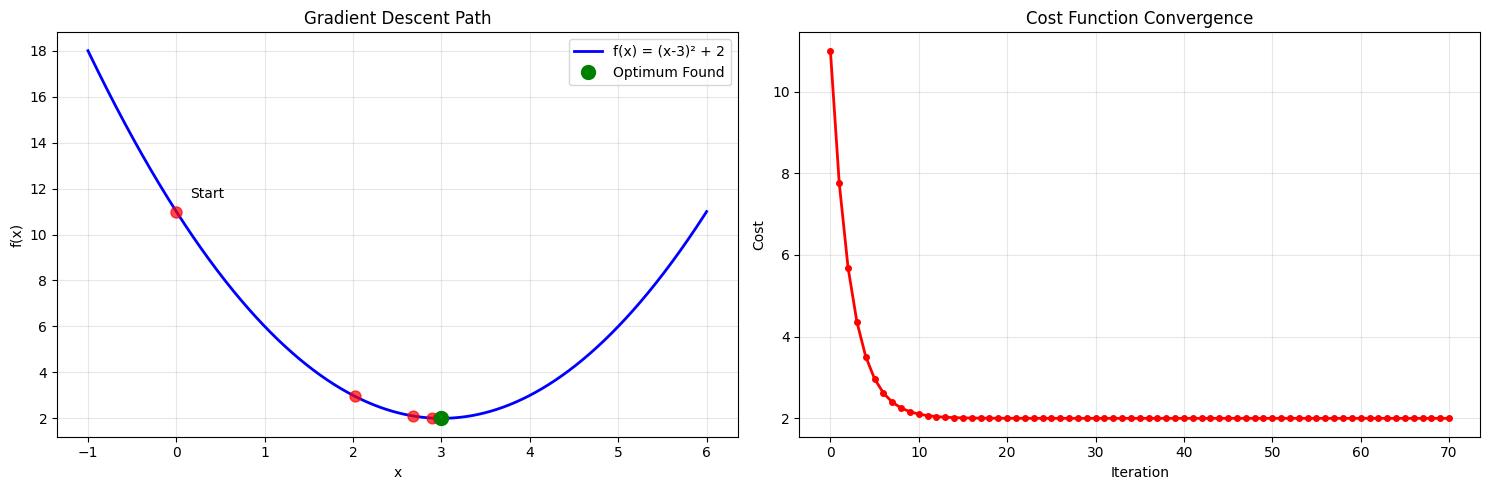

In [9]:
demonstrate_gradient_descent()

In [34]:
# 3. MACHINE LEARNING EXAMPLE: LINEAR REGRESSION
# ===============================
import sklearn as sk
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_iterations=1000):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.cost_history = []
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        """Fit linear regression using gradient descent"""
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient descent
        for i in range(self.max_iterations):
            # Forward pass
            y_pred = np.dot(X, self.weights) + self.bias
            
            # Compute cost (MSE)
            cost = np.mean((y_pred - y)**2)
            self.cost_history.append(cost)
            
            # Compute gradients
            dw = (2/n_samples) * np.dot(X.T, (y_pred - y))
            db = (2/n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

def ml_gradient_descent_example():
    """Demonstrate gradient descent in machine learning context"""
    print("\n=== MACHINE LEARNING EXAMPLE: LINEAR REGRESSION ===")
    
    # Generate sample data
    np.random.seed(42)
    X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
    
    # Fit using our gradient descent implementation
    model_gd = LinearRegressionGD(learning_rate=0.01, max_iterations=1000)
    model_gd.fit(X, y)
    
    # Compare with sklearn
    model_sklearn = LinearRegression()
    model_sklearn.fit(X, y)
    
    print(f"Gradient Descent - Weight: {model_gd.weights[0]:.4f}, Bias: {model_gd.bias:.4f}")
    print(f"Sklearn (Analytical) - Weight: {model_sklearn.coef_[0]:.4f}, Bias: {model_sklearn.intercept_:.4f}")
    
    # Visualize results
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Data and fitted line
    ax1.scatter(X, y, alpha=0.6, label='Data')
    X_sorted = np.sort(X, axis=0)
    y_pred_gd = model_gd.predict(X_sorted)
    y_pred_sklearn = model_sklearn.predict(X_sorted)
    
    ax1.plot(X_sorted, y_pred_gd, 'r-', linewidth=2, label='Gradient Descent')
    ax1.plot(X_sorted, y_pred_sklearn, 'g--', linewidth=2, label='Sklearn (Analytical)')
    ax1.set_title('Linear Regression Comparison')
    ax1.set_xlabel('X')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Cost function convergence
    ax2.plot(model_gd.cost_history, 'b-', linewidth=2)
    ax2.set_title('Cost Function Convergence')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Mean Squared Error')
    ax2.grid(True, alpha=0.3)
    
    # Cost function surface (for visualization)
    w_range = np.linspace(model_gd.weights[0] - 20, model_gd.weights[0] + 20, 50)
    b_range = np.linspace(model_gd.bias - 20, model_gd.bias + 20, 50)
    W, B = np.meshgrid(w_range, b_range)
    
    # Calculate cost for each combination
    costs = np.zeros_like(W)
    for i in range(len(w_range)):
        for j in range(len(b_range)):
            y_pred = X.ravel() * W[j, i] + B[j, i]
            costs[j, i] = np.mean((y_pred - y)**2)
    
    contour = ax3.contour(W, B, costs, levels=20)
    ax3.clabel(contour, inline=True, fontsize=8)
    ax3.plot(model_gd.weights[0], model_gd.bias, 'ro', markersize=10, label='GD Solution')
    ax3.plot(model_sklearn.coef_[0], model_sklearn.intercept_, 'go', markersize=10, label='Analytical Solution')
    ax3.set_title('Cost Function Surface')
    ax3.set_xlabel('Weight')
    ax3.set_ylabel('Bias')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()


=== MACHINE LEARNING EXAMPLE: LINEAR REGRESSION ===
Gradient Descent - Weight: 44.4372, Bias: 1.1651
Sklearn (Analytical) - Weight: 44.4372, Bias: 1.1651


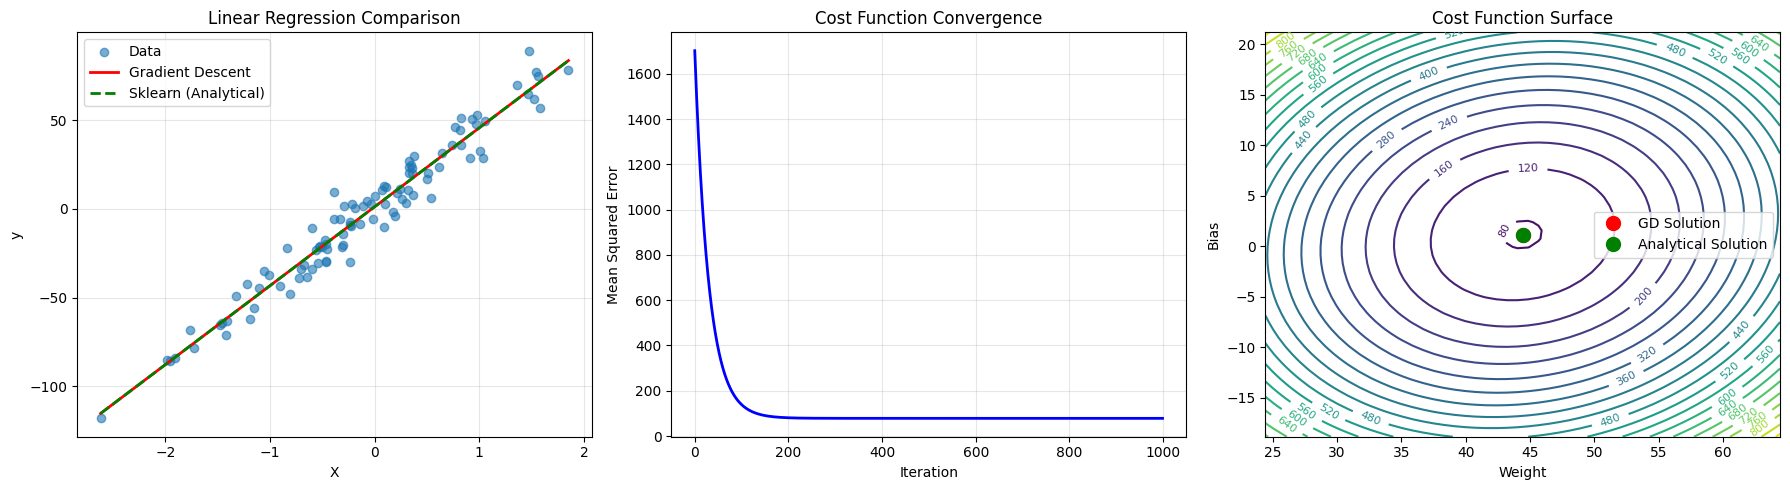

In [35]:
ml_gradient_descent_example()

In [36]:
# ===============================
# 4. DIFFERENT OPTIMIZATION ALGORITHMS COMPARISON
# ===============================

def compare_optimization_algorithms():
    """Compare different optimization algorithms"""
    print("\n=== OPTIMIZATION ALGORITHMS COMPARISON ===")
    
    # Define a more complex function for comparison
    def complex_function(x):
        return x**4 - 4*x**3 + 4*x**2 + 0.1*x + 1
    
    def complex_gradient(x):
        return 4*x**3 - 12*x**2 + 8*x + 0.1
    
    algorithms = {
        'Gradient Descent (lr=0.01)': GradientDescent(0.01, 200),
        'Gradient Descent (lr=0.1)': GradientDescent(0.1, 200),
        'Gradient Descent (lr=0.5)': GradientDescent(0.5, 200)
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    # Plot original function
    x_range = np.linspace(-0.5, 3, 1000)
    y_range = complex_function(x_range)
    
    for i, (name, optimizer) in enumerate(algorithms.items()):
        ax = axes[i]
        ax.plot(x_range, y_range, 'b-', linewidth=2, alpha=0.7, label='f(x)')
        
        # Run optimization
        initial_x = np.array([2.5])
        optimal_x, optimal_cost = optimizer.optimize(
            complex_function, complex_gradient, initial_x
        )
        
        # Plot optimization path
        x_history = [record['x'][0] for record in optimizer.history]
        y_history = [record['cost'] for record in optimizer.history]
        
        ax.plot(x_history, y_history, 'ro-', markersize=4, alpha=0.7, label='Optimization Path')
        ax.plot(optimal_x, optimal_cost, 'go', markersize=10, label=f'Final: x={optimal_x[0]:.3f}')
        
        ax.set_title(f'{name}\nIterations: {len(optimizer.history)}')
        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    # Convergence comparison
    ax = axes[3]
    for name, optimizer in algorithms.items():
        costs = [record['cost'] for record in optimizer.history]
        ax.plot(costs, label=name, linewidth=2)
    
    ax.set_title('Convergence Comparison')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cost')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()


=== OPTIMIZATION ALGORITHMS COMPARISON ===
Converged after 182 iterations
final gredicent s [9.48704683e-07]
Converged after 12 iterations
final gredicent s [-8.62428505e-07]


/var/folders/68/hjr0dmf11mdcgw23xxzbtqzc0000gn/T/ipykernel_11080/464969043.py:11: RuntimeWarning: overflow encountered in power
  return x**4 - 4*x**3 + 4*x**2 + 0.1*x + 1
/var/folders/68/hjr0dmf11mdcgw23xxzbtqzc0000gn/T/ipykernel_11080/464969043.py:11: RuntimeWarning: invalid value encountered in subtract
  return x**4 - 4*x**3 + 4*x**2 + 0.1*x + 1
/var/folders/68/hjr0dmf11mdcgw23xxzbtqzc0000gn/T/ipykernel_11080/464969043.py:14: RuntimeWarning: overflow encountered in power
  return 4*x**3 - 12*x**2 + 8*x + 0.1
/var/folders/68/hjr0dmf11mdcgw23xxzbtqzc0000gn/T/ipykernel_11080/464969043.py:11: RuntimeWarning: invalid value encountered in add
  return x**4 - 4*x**3 + 4*x**2 + 0.1*x + 1
/var/folders/68/hjr0dmf11mdcgw23xxzbtqzc0000gn/T/ipykernel_11080/3927588929.py:33: RuntimeWarning: invalid value encountered in subtract
  x = x - self.learning_rate * gradient


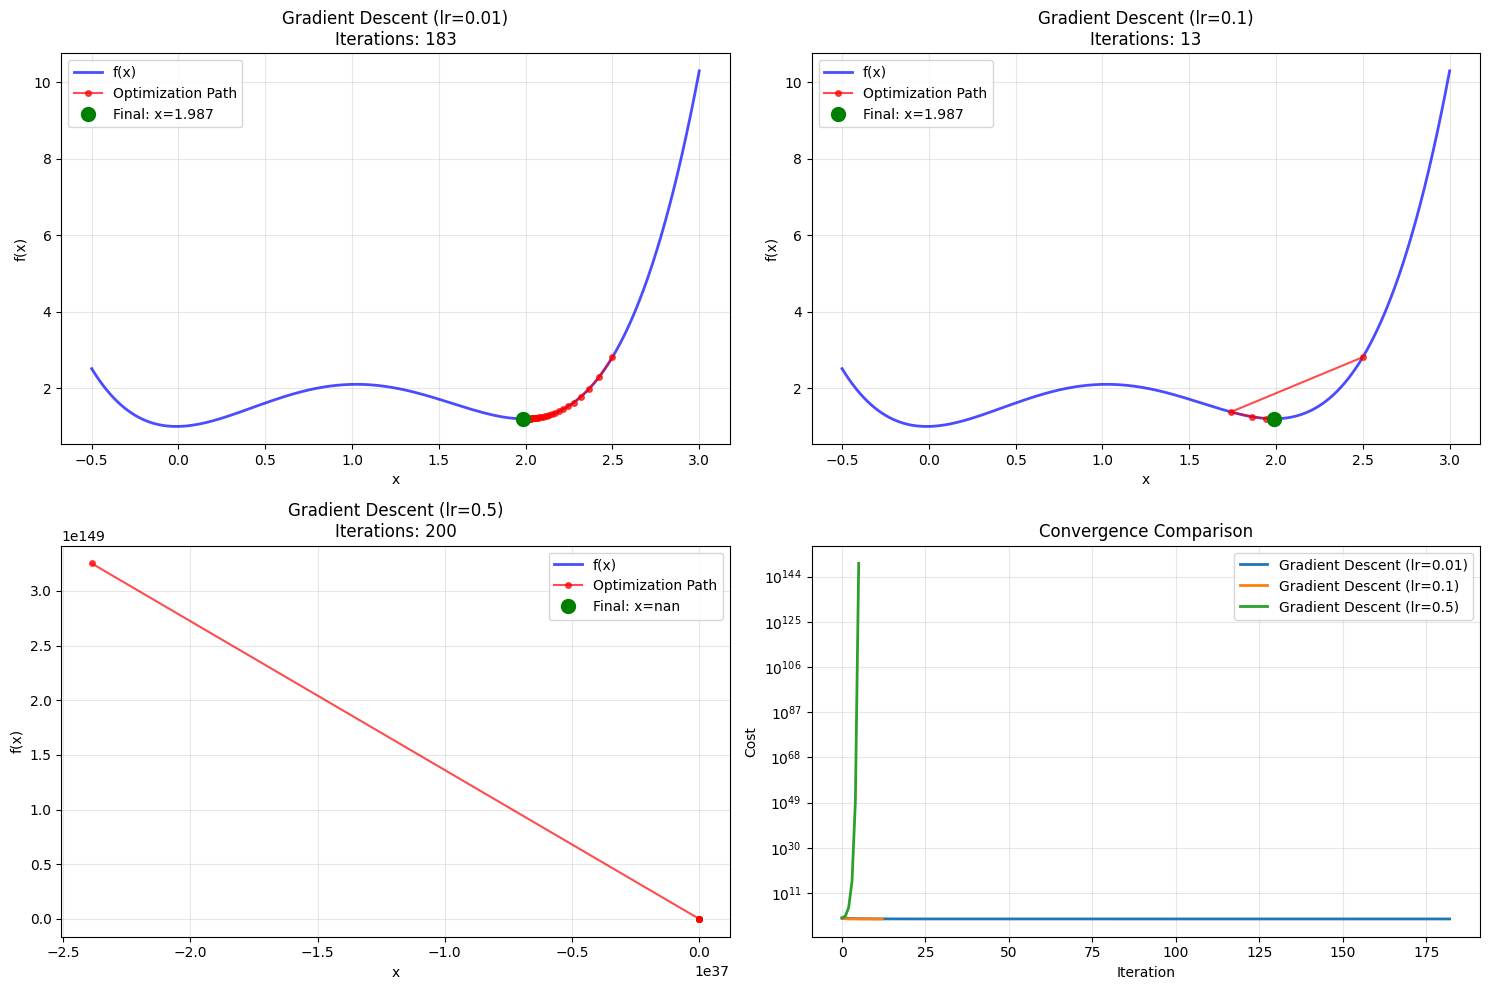

In [37]:
compare_optimization_algorithms()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import seaborn as sns
from scipy.optimize import minimize
import torch
import torch.nn as nn

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ===============================
# 1. PARTIAL DERIVATIVES
# ===============================

def example_function(x, y):
    """Example function: f(x,y) = x^2 + xy + y^2"""
    return x**2 + x*y + y**2

def partial_x(x, y):
    """Partial derivative with respect to x: ∂f/∂x = 2x + y"""
    return 2*x + y

def partial_y(x, y):
    """Partial derivative with respect to y: ∂f/∂y = x + 2y"""
    return x + 2*y

def numerical_partial_derivative(f, x, y, var='x', h=1e-8):
    """Compute partial derivative numerically for verification"""
    if var == 'x':
        return (f(x + h, y) - f(x, y)) / h
    elif var == 'y':
        return (f(x, y + h) - f(x, y)) / h

def demonstrate_partial_derivatives():
    """Demonstrate partial derivatives with visualization"""
    print("=== PARTIAL DERIVATIVES DEMONSTRATION ===")
    
    # Test point
    x0, y0 = 1.0, 2.0
    
    # Analytical partial derivatives
    px_analytical = partial_x(x0, y0)
    py_analytical = partial_y(x0, y0)
    
    # Numerical partial derivatives
    px_numerical = numerical_partial_derivative(example_function, x0, y0, 'x')
    py_numerical = numerical_partial_derivative(example_function, x0, y0, 'y')
    
    print(f"At point ({x0}, {y0}):")
    print(f"f({x0}, {y0}) = {example_function(x0, y0)}")
    print(f"∂f/∂x = {px_analytical:.6f} (analytical), {px_numerical:.6f} (numerical)")
    print(f"∂f/∂y = {py_analytical:.6f} (analytical), {py_numerical:.6f} (numerical)")
    
    # Visualize partial derivatives
    fig = plt.figure(figsize=(18, 12))
    
    # 3D surface plot
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    x_range = np.linspace(-3, 3, 50)
    y_range = np.linspace(-3, 3, 50)
    X, Y = np.meshgrid(x_range, y_range)
    Z = example_function(X, Y)
    
    surface = ax1.plot_surface(X, Y, Z, alpha=0.7, cmap='viridis')
    ax1.scatter([x0], [y0], [example_function(x0, y0)], color='red', s=100)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')
    ax1.set_title('3D Surface: f(x,y) = x² + xy + y²')
    
    # Partial derivative with respect to x (fix y)
    ax2 = fig.add_subplot(2, 3, 2)
    x_slice = np.linspace(-3, 3, 100)
    y_fixed = y0
    z_slice = example_function(x_slice, y_fixed)
    
    ax2.plot(x_slice, z_slice, 'b-', linewidth=2, label=f'f(x, {y_fixed})')
    ax2.scatter([x0], [example_function(x0, y0)], color='red', s=100, zorder=5)
    
    # Tangent line
    tangent_x = np.linspace(x0-1, x0+1, 50)
    tangent_z = example_function(x0, y0) + px_analytical * (tangent_x - x0)
    ax2.plot(tangent_x, tangent_z, 'r--', linewidth=2, label=f'Tangent (slope={px_analytical:.2f})')
    
    ax2.set_xlabel('x')
    ax2.set_ylabel('f(x,y)')
    ax2.set_title(f'Partial Derivative ∂f/∂x at y={y_fixed}')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Partial derivative with respect to y (fix x)
    ax3 = fig.add_subplot(2, 3, 3)
    y_slice = np.linspace(-3, 3, 100)
    x_fixed = x0
    z_slice = example_function(x_fixed, y_slice)
    
    ax3.plot(y_slice, z_slice, 'g-', linewidth=2, label=f'f({x_fixed}, y)')
    ax3.scatter([y0], [example_function(x0, y0)], color='red', s=100, zorder=5)
    
    # Tangent line
    tangent_y = np.linspace(y0-1, y0+1, 50)
    tangent_z = example_function(x0, y0) + py_analytical * (tangent_y - y0)
    ax3.plot(tangent_y, tangent_z, 'r--', linewidth=2, label=f'Tangent (slope={py_analytical:.2f})')
    
    ax3.set_xlabel('y')
    ax3.set_ylabel('f(x,y)')
    ax3.set_title(f'Partial Derivative ∂f/∂y at x={x_fixed}')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Mixed partial derivative visualization
    ax4 = fig.add_subplot(2, 3, 4)
    
    # Show how ∂f/∂x changes as y changes
    y_values = np.linspace(-2, 2, 5)
    x_plot = np.linspace(-3, 3, 100)
    
    for y_val in y_values:
        px_values = partial_x(x_plot, y_val)
        ax4.plot(x_plot, px_values, label=f'∂f/∂x at y={y_val:.1f}')
    
    ax4.set_xlabel('x')
    ax4.set_ylabel('∂f/∂x')
    ax4.set_title('How ∂f/∂x Changes with y')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # Show second partial derivatives
    ax5 = fig.add_subplot(2, 3, 5)
    
    # Second partial derivatives
    def second_partial_xx(x, y):
        return 2.0  # ∂²f/∂x² = 2
    
    def second_partial_yy(x, y):
        return 2.0  # ∂²f/∂y² = 2
    
    def second_partial_xy(x, y):
        return 1.0  # ∂²f/∂x∂y = 1
    
    x_test = np.linspace(-2, 2, 10)
    y_test = np.linspace(-2, 2, 10)
    
    ax5.text(0.1, 0.9, f'∂²f/∂x² = {second_partial_xx(0,0):.1f}', transform=ax5.transAxes, fontsize=14)
    ax5.text(0.1, 0.8, f'∂²f/∂y² = {second_partial_yy(0,0):.1f}', transform=ax5.transAxes, fontsize=14)
    ax5.text(0.1, 0.7, f'∂²f/∂x∂y = {second_partial_xy(0,0):.1f}', transform=ax5.transAxes, fontsize=14)
    ax5.text(0.1, 0.6, 'Mixed partials are equal!', transform=ax5.transAxes, fontsize=12, style='italic')
    ax5.set_title('Second Partial Derivatives')
    ax5.axis('off')
    
    # Hessian matrix visualization
    ax6 = fig.add_subplot(2, 3, 6)
    
    # Hessian matrix
    H = np.array([[2, 1], [1, 2]])  # [[∂²f/∂x², ∂²f/∂x∂y], [∂²f/∂y∂x, ∂²f/∂y²]]
    
    im = ax6.imshow(H, cmap='RdBu', aspect='equal')
    ax6.set_xticks([0, 1])
    ax6.set_yticks([0, 1])
    ax6.set_xticklabels(['x', 'y'])
    ax6.set_yticklabels(['x', 'y'])
    ax6.set_title('Hessian Matrix H')
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            ax6.text(j, i, f'{H[i,j]:.1f}', ha='center', va='center', fontsize=16, fontweight='bold')
    
    plt.colorbar(im, ax=ax6, shrink=0.6)
    
    plt.tight_layout()
    plt.show()

# ===============================
# 2. GRADIENT VECTORS
# ===============================

def gradient_vector(x, y):
    """Gradient vector: ∇f = (∂f/∂x, ∂f/∂y)"""
    return np.array([partial_x(x, y), partial_y(x, y)])

def demonstrate_gradient_vectors():
    """Demonstrate gradient vectors with visualization"""
    print("\n=== GRADIENT VECTORS DEMONSTRATION ===")
    
    # Create a more interesting function for gradient visualization
    def complex_function(x, y):
        return np.sin(x) * np.cos(y) + 0.1 * (x**2 + y**2)
    
    def complex_gradient(x, y):
        dx = np.cos(x) * np.cos(y) + 0.2 * x
        dy = -np.sin(x) * np.sin(y) + 0.2 * y
        return np.array([dx, dy])
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Gradient field visualization
    x_range = np.linspace(-3, 3, 15)
    y_range = np.linspace(-3, 3, 15)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Compute gradients at each point
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            grad = complex_gradient(X[j,i], Y[j,i])
            U[j,i] = grad[0]
            V[j,i] = grad[1]
    
    # Normalize for better visualization
    magnitude = np.sqrt(U**2 + V**2)
    U_norm = U / (magnitude + 1e-10)
    V_norm = V / (magnitude + 1e-10)
    
    ax1.quiver(X, Y, U_norm, V_norm, magnitude, cmap='plasma', alpha=0.7)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Gradient Vector Field')
    ax1.set_aspect('equal')
    
    # 2. Contour plot with gradient vectors
    x_fine = np.linspace(-3, 3, 100)
    y_fine = np.linspace(-3, 3, 100)
    X_fine, Y_fine = np.meshgrid(x_fine, y_fine)
    Z_fine = complex_function(X_fine, Y_fine)
    
    contour = ax2.contour(X_fine, Y_fine, Z_fine, levels=20, alpha=0.6)
    ax2.clabel(contour, inline=True, fontsize=8)
    
    # Add gradient vectors at selected points
    test_points = [(-2, -1), (0, 0), (1, 1), (-1, 2)]
    for point in test_points:
        grad = complex_gradient(point[0], point[1])
        ax2.arrow(point[0], point[1], grad[0]*0.3, grad[1]*0.3, 
                 head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2)
    
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Gradient Vectors ⊥ to Level Curves')
    ax2.set_aspect('equal')
    
    # 3. Gradient magnitude visualization
    magnitude_fine = np.sqrt(
        complex_gradient(X_fine, Y_fine)[0]**2 + 
        complex_gradient(X_fine, Y_fine)[1]**2
    )
    
    im = ax3.imshow(magnitude_fine, extent=[-3, 3, -3, 3], 
                    origin='lower', cmap='hot', aspect='equal')
    plt.colorbar(im, ax=ax3, label='||∇f||')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    ax3.set_title('Gradient Magnitude ||∇f||')
    
    # 4. Gradient descent path
    def gradient_descent_path(start_point, learning_rate=0.1, num_steps=50):
        path = [start_point]
        current = np.array(start_point)
        
        for _ in range(num_steps):
            grad = complex_gradient(current[0], current[1])
            current = current - learning_rate * grad
            path.append(current.copy())
            
            # Stop if gradient is very small
            if np.linalg.norm(grad) < 1e-6:
                break
        
        return np.array(path)
    
    # Multiple starting points
    start_points = [(-2, 2), (2, -2), (-2, -2), (2, 2)]
    colors = ['red', 'blue', 'green', 'orange']
    
    ax4.contour(X_fine, Y_fine, Z_fine, levels=20, alpha=0.3)
    
    for start, color in zip(start_points, colors):
        path = gradient_descent_path(start)
        ax4.plot(path[:, 0], path[:, 1], color=color, linewidth=2, 
                marker='o', markersize=3, label=f'Start: {start}')
        ax4.scatter(start[0], start[1], color=color, s=100, marker='s', zorder=5)
    
    ax4.set_xlabel('x')
    ax4.set_ylabel('y')
    ax4.set_title('Gradient Descent Paths')
    ax4.legend()
    ax4.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

# ===============================
# 3. MULTIVARIABLE CHAIN RULE
# ===============================

def demonstrate_chain_rule():
    """Demonstrate multivariable chain rule"""
    print("\n=== MULTIVARIABLE CHAIN RULE DEMONSTRATION ===")
    
    # Example: z = f(x,y) = x²y + y², where x = t², y = sin(t)
    def z_function(t):
        x = t**2
        y = np.sin(t)
        return x**2 * y + y**2
    
    def chain_rule_derivative(t):
        """Analytical derivative using chain rule"""
        x = t**2
        y = np.sin(t)
        
        # Partial derivatives of f
        df_dx = 2*x*y  # ∂f/∂x = 2xy
        df_dy = x**2 + 2*y  # ∂f/∂y = x² + 2y
        
        # Derivatives of x and y with respect to t
        dx_dt = 2*t  # dx/dt = 2t
        dy_dt = np.cos(t)  # dy/dt = cos(t)
        
        # Chain rule: dz/dt = (∂f/∂x)(dx/dt) + (∂f/∂y)(dy/dt)
        return df_dx * dx_dt + df_dy * dy_dt
    
    def numerical_derivative(t, h=1e-8):
        """Numerical derivative for verification"""
        return (z_function(t + h) - z_function(t)) / h
    
    # Test at several points
    test_points = [0, np.pi/4, np.pi/2, np.pi, 3*np.pi/2]
    
    print("Chain Rule Verification:")
    print("t\t\tAnalytical\tNumerical\tError")
    print("-" * 50)
    
    for t in test_points:
        analytical = chain_rule_derivative(t)
        numerical = numerical_derivative(t)
        error = abs(analytical - numerical)
        print(f"{t:.4f}\t\t{analytical:.6f}\t{numerical:.6f}\t{error:.2e}")
    
    # Visualize the process
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    t_range = np.linspace(0, 2*np.pi, 1000)
    
    # 1. Component functions x(t) and y(t)
    x_t = t_range**2
    y_t = np.sin(t_range)
    
    ax1.plot(t_range, x_t, 'b-', linewidth=2, label='x(t) = t²')
    ax1.plot(t_range, y_t, 'r-', linewidth=2, label='y(t) = sin(t)')
    ax1.set_xlabel('t')
    ax1.set_ylabel('x(t), y(t)')
    ax1.set_title('Component Functions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Parametric curve in x-y plane
    ax2.plot(x_t, y_t, 'g-', linewidth=2, label='Parametric curve (x(t), y(t))')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Parametric Curve in x-y Plane')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Composite function z(t)
    z_t = z_function(t_range)
    ax3.plot(t_range, z_t, 'purple', linewidth=2, label='z(t) = f(x(t), y(t))')
    ax3.set_xlabel('t')
    ax3.set_ylabel('z')
    ax3.set_title('Composite Function')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Derivative comparison
    analytical_deriv = chain_rule_derivative(t_range)
    numerical_deriv = np.gradient(z_t, t_range)
    
    ax4.plot(t_range, analytical_deriv, 'b-', linewidth=2, label='Analytical (Chain Rule)')
    ax4.plot(t_range, numerical_deriv, 'r--', linewidth=2, label='Numerical')
    ax4.set_xlabel('t')
    ax4.set_ylabel('dz/dt')
    ax4.set_title('Derivative Comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ===============================
# 4. BACKPROPAGATION EXAMPLE
# ===============================

class SimpleNeuralNetwork:
    """Simple neural network to demonstrate backpropagation"""
    def __init__(self):
        # Initialize weights
        self.W1 = np.random.randn(2, 3) * 0.1  # Input to hidden
        self.b1 = np.zeros((1, 3))  # Hidden bias
        self.W2 = np.random.randn(3, 1) * 0.1  # Hidden to output
        self.b2 = np.zeros((1, 1))  # Output bias
        
        # Store intermediate values for backprop
        self.z1 = None
        self.a1 = None
        self.z2 = None
        self.a2 = None
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))
    
    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self, X):
        """Forward pass"""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, output):
        """Backward pass using chain rule"""
        m = X.shape[0]
        
        # Output layer gradients
        dz2 = output - y
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        
        # Hidden layer gradients (chain rule applied here!)
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.sigmoid_derivative(self.z1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        
        return dW1, db1, dW2, db2
    
    def train_step(self, X, y, learning_rate=0.1):
        """Single training step"""
        # Forward pass
        output = self.forward(X)
        
        # Backward pass
        dW1, db1, dW2, db2 = self.backward(X, y, output)
        
        # Update weights
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        
        # Compute loss
        loss = np.mean((output - y)**2)
        return loss

def demonstrate_backpropagation():
    """Demonstrate backpropagation with chain rule"""
    print("\n=== BACKPROPAGATION DEMONSTRATION ===")
    
    # Generate XOR dataset
    np.random.seed(42)
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])  # XOR function
    
    # Create and train network
    network = SimpleNeuralNetwork()
    losses = []
    
    print("Training neural network on XOR problem...")
    for epoch in range(2000):
        loss = network.train_step(X, y, learning_rate=1.0)